# 04 Random Forest Demand Model

## Goal
Train a Random Forest model to predict department-level demand.

## Input
`data/processed_demand_data.csv`

## Notes
Demand is highly skewed, so the model is trained on `log_demand`.
Predictions are converted back to real demand before evaluation.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
demand_data = pd.read_csv("/Users/ayu/Desktop/AI_Grocery_Demand_Forecasting/notebooks/data/processed_demand_data.csv")
demand_data.head()

,day_of_week,hour,dept_name,demand,is_weekend,hour_sin,hour_cos,dept_encoded,log_demand
0,0,0,alcohol,52,1,0.0,1.0,0,3.970292
1,0,0,babies,400,1,0.0,1.0,1,5.993961
2,0,0,bakery,1301,1,0.0,1.0,2,7.171657
3,0,0,beverages,2970,1,0.0,1.0,3,7.996654
4,0,0,breakfast,721,1,0.0,1.0,4,6.582025


## 1. Define Features and Target

In [3]:
X = demand_data[['day_of_week', 'hour', 'is_weekend', 'hour_sin', 'hour_cos', 'dept_encoded']]
y = demand_data['log_demand']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2822, 6)
X_test shape: (706, 6)


## 2. Train Random Forest Model

In [5]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 3. Predict and Convert Back to Real Demand

In [6]:
log_predictions = rf_model.predict(X_test)

predictions = np.expm1(log_predictions)
actual = np.expm1(y_test)

## 4. Evaluate Model

In [7]:
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("Random Forest MAE:", mae)
print("Random Forest RMSE:", rmse)

Random Forest MAE: 644.403386952543
Random Forest RMSE: 1756.0721633692299


## 5. Feature Importance

In [8]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
5,dept_encoded,0.545696
1,hour,0.383790
4,hour_cos,0.045892
3,hour_sin,0.017626
0,day_of_week,0.005847
2,is_weekend,0.001148


## 6. Actual vs Predicted Demand

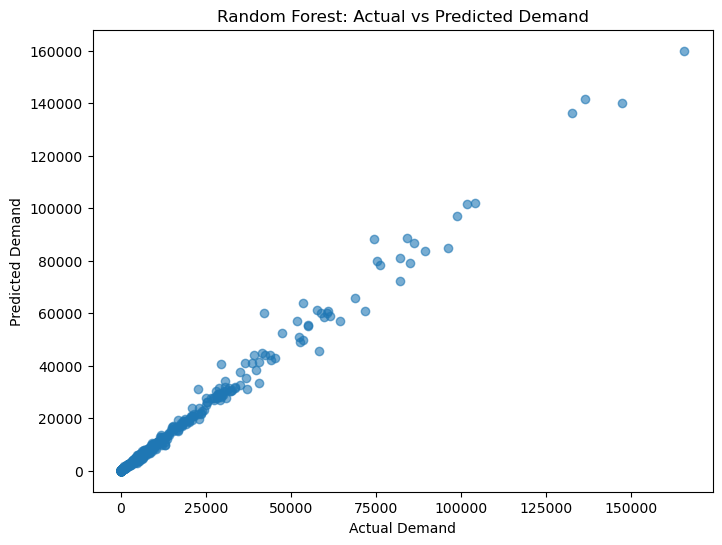

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(actual, predictions, alpha=0.6)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Random Forest: Actual vs Predicted Demand")
plt.show()

## Key Takeaways
- Random Forest provides a strong baseline for demand forecasting.
- Log transformation helps stabilize extreme demand spikes.
- Department and hour are the main demand drivers.

## Next notebook
`05_xgboost_model.ipynb`